In [1]:
%load_ext autoreload
%autoreload 2

**Author:** Salvador Navas  
**Date:** 2025-06-27

### SoilGrids — Global Soil Information (ISRIC)

**SoilGrids** provides global predictions of soil properties at multiple depths,
derived from machine learning models trained on ~240,000 field observations and
remote sensing covariates (DEM, climate, vegetation indices).

| Property | Value |
|----------|-------|
| Provider | ISRIC – World Soil Information (https://www.isric.org) |
| Spatial resolution | 250 m (~0.002°) globally |
| Depth layers | 7 standard layers: 0–5, 5–15, 15–30, 30–60, 60–100, 100–200 cm |
| Variables | Sand, Silt, Clay (%), Organic Carbon, pH, Bulk Density, CEC |
| Format | GeoTIFF (uint8, values 0–100 = %; 255 = no data) |
| License | **CC BY 4.0** — free for any use with attribution |

#### ⚠️ SoilGrids is a prediction, not a measurement

SoilGrids uses machine learning to extrapolate soil properties from a limited set of
field observations. Prediction uncertainty is high in data-sparse regions (Africa,
Central Asia, Amazon) and for deep layers (>60 cm). Always check the provided
**uncertainty maps** (5th and 95th percentile layers) before using in design.

#### 🔗 Connection to hydrological properties

Soil texture (sand/silt/clay) determines key hydrological parameters:

| USDA Class | Saturated conductivity Ks | CN (AMC II) | Typical use |
|------------|--------------------------|-------------|-------------|
| Sand / Loamy Sand | 50–200 mm/h | 61–77 (HSG A) | Low runoff, high infiltration |
| Sandy Loam / Loam | 10–50 mm/h | 69–84 (HSG B) | Moderate |
| Clay Loam / Silty Clay Loam | 1–10 mm/h | 79–90 (HSG C) | Higher runoff |
| Clay / Silty Clay | 0.1–1 mm/h | 84–94 (HSG D) | Low infiltration, high runoff |

> **HSG** = Hydrologic Soil Group (NRCS classification used in CN method)

#### 🔧 Downloading real SoilGrids data

Real data requires the **GDAL library** and internet access:

```python
from pyhydra.data_sources.soils import download_soilgrids, open_soilgrids_geotif

# Download sand content at surface (0-5 cm) for Iberian Peninsula
download_soilgrids(
    variable='SNDPPT',      # SNDPPT=sand, SLTPPT=silt, CLYPPT=clay
    depth='sl1',            # sl1=0-5cm, sl2=5-15cm, ... sl7=100-200cm
    bbox=(-10, 35, 5, 44), # (lon_min, lat_min, lon_max, lat_max)
    output_dir='soilgrids/'
)
sand = open_soilgrids_geotif('soilgrids/SNDPPT_sl1.tif')
```

#### 📋 Workflow overview (demo mode)

| Step | Action | Output |
|------|--------|--------|
| 1 | Synthetic sand/silt/clay grids | 10×20 numpy arrays |
| 2 | Single-point USDA classification | `find_usda_soilclass` examples |
| 3 | USDA triangle visualisation | Classification boundary plot |
| 4 | Full grid classification map | PNG map |
| 5 | Modal class across 7 depths | `scipy.stats.mode` approach |

> **Note (demo mode):** This notebook uses **synthetic** sand/silt/clay arrays.
> In production, replace with real GeoTIFFs from `download_soilgrids()` (requires GDAL).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.stats

from pyhydra.data_sources.soils import find_usda_soilclass

In [3]:
# USDA soil texture class names (class index 1–12)
SOIL_TYPES = [
    'Clay', 'Clay Loam', 'Loam', 'Loamy Sand', 'Sand',
    'Sandy Clay', 'Sandy Clay Loam', 'Sandy Loam',
    'Silt', 'Silty Clay', 'Silty Clay Loam', 'Silt Loam',
]
print('USDA classes:', SOIL_TYPES)

USDA classes: ['Clay', 'Clay Loam', 'Loam', 'Loamy Sand', 'Sand', 'Sandy Clay', 'Sandy Clay Loam', 'Sandy Loam', 'Silt', 'Silty Clay', 'Silty Clay Loam', 'Silt Loam']


---
## 1. Synthetic soil fraction grids

We create a small **10 rows × 20 columns** grid where sand, silt and clay percentages
vary smoothly from sandy soils in the west to clayey soils in the east.
This gradient mimics a real transition (e.g., fluvial sediments → clay-rich floodplain).

**Constraint:** `sand + silt + clay = 100` at every pixel (they are fractions of the mineral fraction).

In real SoilGrids data, pixels are `uint8` (0–100), and value 255 means no data.
pyhydra handles the 255→NaN conversion automatically in `open_soilgrids_geotif()`.


In [4]:
rng = np.random.default_rng(42)
ROWS, COLS = 10, 20

# Base gradient: sand decreases left→right, clay increases
sand_base = np.linspace(70, 10, COLS)   # % sand
clay_base = np.linspace( 5, 45, COLS)   # % clay
silt_base = 100 - sand_base - clay_base  # remainder

# Broadcast to 2-D and add mild row-wise noise
sand = np.clip(np.tile(sand_base, (ROWS, 1)) + rng.uniform(-5, 5, (ROWS, COLS)), 0, 100)
clay = np.clip(np.tile(clay_base, (ROWS, 1)) + rng.uniform(-5, 5, (ROWS, COLS)), 0, 100)
silt = np.clip(100 - sand - clay, 0, 100)

# Convert to uint8 (same dtype as real SoilGrids data)
sand = sand.astype(np.uint8)
silt = silt.astype(np.uint8)
clay = clay.astype(np.uint8)

print(f'Grid shape : {sand.shape}')
print(f'Sand  range: {sand.min()}-{sand.max()} %')
print(f'Silt  range: {silt.min()}-{silt.max()} %')
print(f'Clay  range: {clay.min()}-{clay.max()} %')

Grid shape : (10, 20)
Sand  range: 5-74 %
Silt  range: 17-51 %
Clay  range: 0-49 %


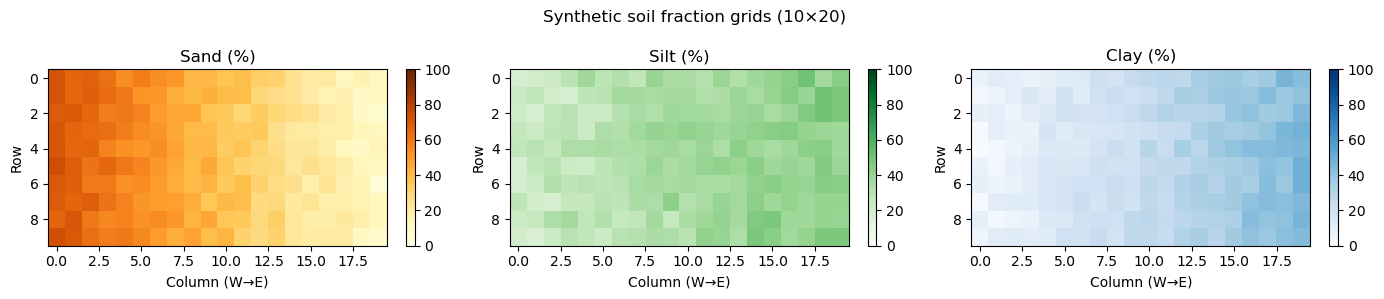

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, arr, label, cmap in zip(
        axes,
        [sand, silt, clay],
        ['Sand (%)', 'Silt (%)', 'Clay (%)'],
        ['YlOrBr', 'Greens', 'Blues']):
    im = ax.imshow(arr, cmap=cmap, vmin=0, vmax=100, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.05)
    ax.set_title(label)
    ax.set_xlabel('Column (W→E)')
    ax.set_ylabel('Row')
fig.suptitle('Synthetic soil fraction grids (10×20)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 2. USDA soil texture classification

`find_usda_soilclass(sand, silt, clay)` classifies every pixel into one of 12 USDA
texture classes using the standard triangle thresholds. It works on scalar values or
numpy arrays of any shape.

### 2a. Single-point example

In [6]:
# Classify a single representative point
examples = [
    (70, 20, 10, 'Sandy / top-left area'),
    (40, 40, 20, 'Loam / central area'),
    (10, 45, 45, 'Clay / right area'),
]

print(f"{'Sand':>6} {'Silt':>6} {'Clay':>6}  ->  Class  Name")
print('-' * 55)
for s, si, c, desc in examples:
    cls_arr, names = find_usda_soilclass(
        np.array([[s]], dtype=np.uint8),
        np.array([[si]], dtype=np.uint8),
        np.array([[c]], dtype=np.uint8),
    )
    cls = int(cls_arr[0, 0])
    name = names[cls - 1] if cls > 0 else 'no data'
    print(f'{s:>6} {si:>6} {c:>6}  ->    {cls:2d}   {name:<20s}  ({desc})')

  Sand   Silt   Clay  ->  Class  Name
-------------------------------------------------------
    70     20     10  ->     8   sandy loam            (Sandy / top-left area)
    40     40     20  ->     3   loam                  (Loam / central area)
    10     45     45  ->    10   silty clay            (Clay / right area)


### 2b. Full grid classification

In [7]:
soilclass, soiltype = find_usda_soilclass(sand, silt, clay)

unique, counts = np.unique(soilclass[soilclass > 0], return_counts=True)
total_valid = (soilclass > 0).sum()
print('USDA classes present in synthetic grid:')
for cls, cnt in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f'  {cls:2d} — {SOIL_TYPES[int(cls)-1]:<20s}: {cnt:3d} pixels ({100*cnt/total_valid:.1f} %)')

USDA classes present in synthetic grid:
   8 — Sandy Loam          :  53 pixels (26.9 %)
   2 — Clay Loam           :  46 pixels (23.4 %)
   3 — Loam                :  46 pixels (23.4 %)
  10 — Silty Clay          :  17 pixels (8.6 %)
  11 — Silty Clay Loam     :  15 pixels (7.6 %)
   1 — Clay                :  13 pixels (6.6 %)
   7 — Sandy Clay Loam     :   5 pixels (2.5 %)
   4 — Loamy Sand          :   2 pixels (1.0 %)


---
## 3. USDA textural triangle — how classification works

The **USDA textural triangle** maps sand/silt/clay percentages to 12 texture classes.
Each coloured region shows one class boundary on the silt–clay plane.

The triangle illustrates a key insight for hydrological modelling:
- Moving **right** (more silt): soil becomes silty, better water retention
- Moving **up** (more clay): soil becomes finer, lower conductivity, higher runoff
- Moving **left** (more sand): soil becomes coarser, faster drainage, lower CN number

The boundaries used here are the standard NRCS/USDA thresholds, the same as in
the SWAT+ and HEC-HMS soil databases.


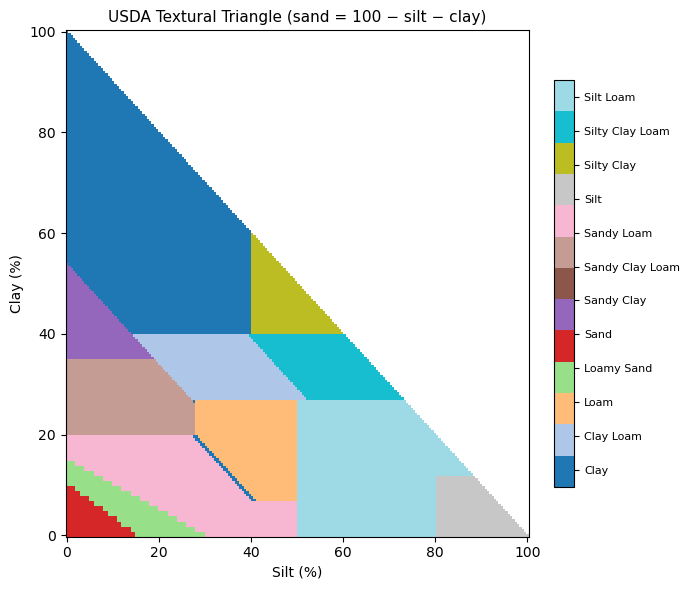

In [8]:
# Build a fine grid of (silt, clay) combinations where sand = 100 - silt - clay >= 0
res = 200
si_range = np.linspace(0, 100, res)
cl_range = np.linspace(0, 100, res)
SI, CL = np.meshgrid(si_range, cl_range)
SA = 100 - SI - CL

# Mask infeasible region (sand < 0)
valid = SA >= 0

# Classify — use 0 as no-data placeholder for infeasible region
sa_c = np.where(valid, SA, 255).astype(np.uint8)
si_c = np.where(valid, SI, 255).astype(np.uint8)
cl_c = np.where(valid, CL, 255).astype(np.uint8)

tri_class, _ = find_usda_soilclass(sa_c, si_c, cl_c)
tri_plot = tri_class.astype(float)
tri_plot[~valid] = np.nan

cmap12 = plt.get_cmap('tab20', 13)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.pcolormesh(si_range, cl_range, tri_plot, cmap=cmap12, vmin=0.5, vmax=12.5)
cbar = plt.colorbar(im, ax=ax, ticks=range(1, 13), fraction=0.04)
cbar.ax.set_yticklabels(SOIL_TYPES, fontsize=8)
ax.set_xlabel('Silt (%)')
ax.set_ylabel('Clay (%)')
ax.set_title('USDA Textural Triangle (sand = 100 − silt − clay)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 4. Synthetic soil class map

Visualise the USDA class assigned to every pixel in the 10×20 synthetic grid
and save the figure to `/tmp/SoilGrids_download.png`.

Figure saved to /tmp/SoilGrids_download.png


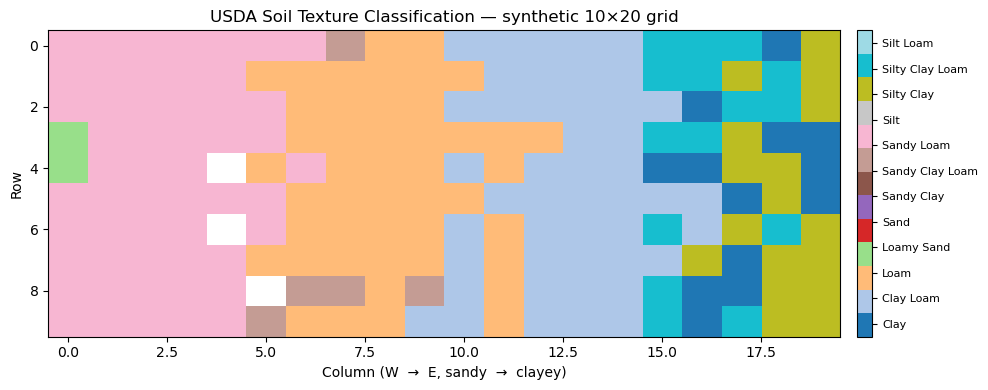

In [9]:
sc_plot = soilclass.astype(float)
sc_plot[sc_plot == 0] = np.nan

cmap12 = plt.get_cmap('tab20', 13)
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(sc_plot, cmap=cmap12, vmin=0.5, vmax=12.5, aspect='auto')
cbar = plt.colorbar(im, ax=ax, ticks=range(1, 13), fraction=0.03, pad=0.02)
cbar.ax.set_yticklabels(SOIL_TYPES, fontsize=8)
ax.set_xlabel('Column (W  →  E, sandy  →  clayey)')
ax.set_ylabel('Row')
ax.set_title('USDA Soil Texture Classification — synthetic 10×20 grid', fontsize=12)
plt.tight_layout()

out_path = '/tmp/SoilGrids_download.png'
plt.savefig(out_path, dpi=150)
plt.show()
print(f'Figure saved to {out_path}')

---
## 5. Modal soil class across depth layers

SoilGrids provides data at **7 standard depths** (sl1–sl7, from 0 to 200 cm).
The **modal (most frequent) class** across depths gives the dominant texture
of the soil profile — more robust than using only the surface layer.

Why this matters for hydrology:
- Infiltration is controlled by the **least permeable layer** (often at depth)
- A surface Sandy Loam over a Clay subsoil behaves hydraulically like Clay (HSG D)
- Use the modal class for CN assignment; use the deepest layer for groundwater recharge estimates


In [10]:
N_DEPTHS = 7
rng2 = np.random.default_rng(7)

depth_classes = []
for d in range(N_DEPTHS):
    s_d = np.clip(sand.astype(int) + rng2.integers(-8, 9, sand.shape), 0, 100).astype(np.uint8)
    si_d = np.clip(silt.astype(int) + rng2.integers(-8, 9, silt.shape), 0, 100).astype(np.uint8)
    c_d = np.clip(clay.astype(int) + rng2.integers(-8, 9, clay.shape), 0, 100).astype(np.uint8)
    cls_d, _ = find_usda_soilclass(s_d, si_d, c_d)
    depth_classes.append(cls_d)

# Stack and compute mode (same logic as extract_mode_soilclass)
stacked = np.dstack(depth_classes)           # shape (10, 20, 7)
mode_result = scipy.stats.mode(stacked, axis=2)[0].squeeze()  # shape (10, 20)

print(f'Stacked shape : {stacked.shape}')
print(f'Mode map shape: {mode_result.shape}')
print('Modal USDA classes present:')
unique_m, counts_m = np.unique(mode_result[mode_result > 0], return_counts=True)
for cls, cnt in sorted(zip(unique_m, counts_m), key=lambda x: -x[1]):
    print(f'  {int(cls):2d} — {SOIL_TYPES[int(cls)-1]:<20s}: {cnt:3d} pixels ({100*cnt/mode_result.size:.1f} %)')

Stacked shape : (10, 20, 7)
Mode map shape: (10, 20)
Modal USDA classes present:
   8 — Sandy Loam          :  55 pixels (27.5 %)
   3 — Loam                :  49 pixels (24.5 %)
   2 — Clay Loam           :  39 pixels (19.5 %)
  10 — Silty Clay          :  20 pixels (10.0 %)
  11 — Silty Clay Loam     :  13 pixels (6.5 %)
   1 — Clay                :  12 pixels (6.0 %)
   4 — Loamy Sand          :   2 pixels (1.0 %)
   7 — Sandy Clay Loam     :   2 pixels (1.0 %)


Done.


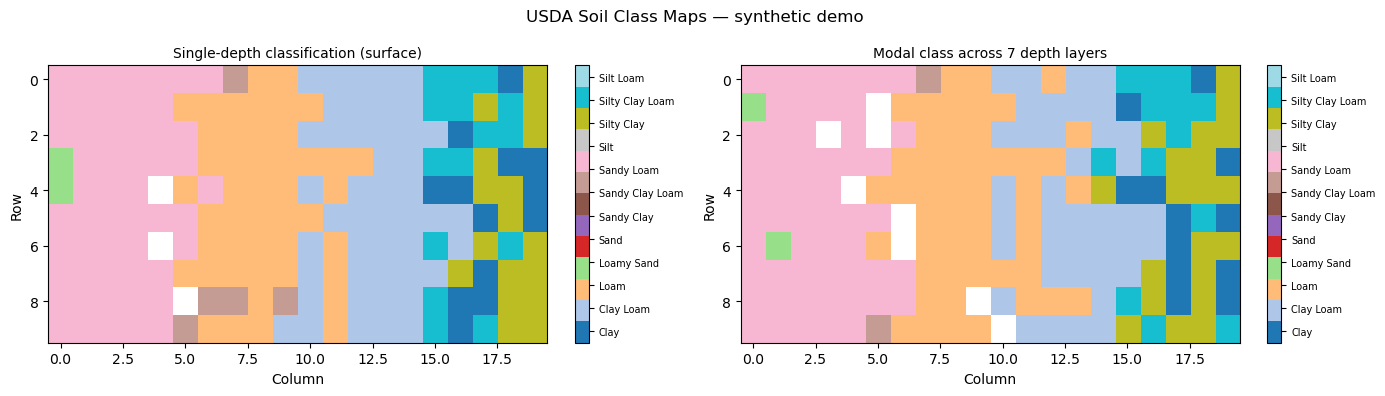

In [11]:
mode_plot = mode_result.astype(float)
mode_plot[mode_plot == 0] = np.nan

cmap12 = plt.get_cmap('tab20', 13)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, data, title in zip(
        axes,
        [sc_plot, mode_plot],
        ['Single-depth classification (surface)', 'Modal class across 7 depth layers']):
    im = ax.imshow(data, cmap=cmap12, vmin=0.5, vmax=12.5, aspect='auto')
    cbar = plt.colorbar(im, ax=ax, ticks=range(1, 13), fraction=0.05)
    cbar.ax.set_yticklabels(SOIL_TYPES, fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')

plt.suptitle('USDA Soil Class Maps — synthetic demo', fontsize=12)
plt.tight_layout()
plt.show()
print('Done.')

---
## 🔗 Using soil texture in hydrological models

#### CN method (SCS/NRCS)

Convert USDA texture class to Hydrologic Soil Group (HSG), then look up CN:

```python
# Approximate mapping USDA class → HSG
usda_to_hsg = {
    'Sand': 'A', 'Loamy Sand': 'A',
    'Sandy Loam': 'B', 'Loam': 'B', 'Silt Loam': 'B', 'Silt': 'B',
    'Sandy Clay Loam': 'C', 'Clay Loam': 'C', 'Silty Clay Loam': 'C',
    'Sandy Clay': 'D', 'Silty Clay': 'D', 'Clay': 'D',
}
hsg = usda_to_hsg.get(soil_class_name, 'B')  # default to B if unknown
```

#### Pedotransfer functions (for SWAT+)

SWAT+ needs hydraulic conductivity (Ksat), field capacity (FC), and wilting point (WP).
These can be estimated from texture using pedotransfer functions (e.g., Saxton & Rawls 2006):

```python
from pyhydra.data_sources.soils import saxton_rawls
Ksat, FC, WP = saxton_rawls(sand_pct=40, silt_pct=40, clay_pct=20, OM_pct=2.0)
```

#### ⚠️ Accuracy reminder

SoilGrids predictions have typical RMSE of:
- Sand: ~15–20% (absolute)
- Clay: ~10–15% (absolute)

This uncertainty can shift a pixel between adjacent texture classes (e.g., Loam ↔ Sandy Loam).
For critical infrastructure design, validate against field soil surveys when available.
